In [14]:
import pandas as pd
import matplotlib.pyplot as plt


In [15]:
CSV_FILE = "pi5_raw_metrics.csv"


# Leer datos
df = pd.read_csv(CSV_FILE)

# # Convertir timestamp
df["timestamp_iso"] = pd.to_datetime(df["timestamp_iso"])
df.head()


,timestamp_iso,cpu_percent,ram_percent,temp_celsius,0V8_AON_A,0V8_AON_V,0V8_SW_A,0V8_SW_V,1V1_SYS_A,1V1_SYS_V,...,DDR_VDDQ_A,DDR_VDDQ_V,EXT5V_V_ERR,HDMI_A,HDMI_V,VDD_CORE_A,VDD_CORE_V,U_A_ERR,U_B,U_C
0,2026-06-23 11:17:41.370110+00:00,0.0,0.0,0.0,0.0,18.6,53.45,0.003968,0.799413,0.486013,...,0.005128,0.000976,1.105127,0.0,0.623076,5.11076,0.013675,5.12282,2.58970,0.975359
1,2026-06-23 11:17:42.400764+00:00,90.4,0.0,30.0,25.0,19.4,53.45,0.004029,0.799120,0.522123,...,0.005128,0.055628,1.110622,0.0,0.607325,5.10004,0.013919,5.10942,3.61665,0.976165
2,2026-06-23 11:17:43.446358+00:00,100.0,0.0,28.4,34.7,20.7,55.10,0.004151,0.799413,0.495772,...,0.005128,0.047821,1.109156,0.0,0.606593,5.10004,0.014164,5.11880,3.78632,0.976165
3,2026-06-23 11:17:44.472508+00:00,71.8,0.0,30.2,35.8,21.2,53.45,0.003907,0.799413,0.487965,...,0.005128,0.005856,1.104394,0.0,0.615018,5.10004,0.013797,5.11344,2.08962,0.910890
4,2026-06-23 11:17:45.499630+00:00,4.9,0.0,29.1,30.9,21.2,52.90,0.004090,0.799120,0.484061,...,0.005128,0.005856,1.110988,0.0,0.617582,5.10138,0.013919,5.10272,2.07176,0.910890


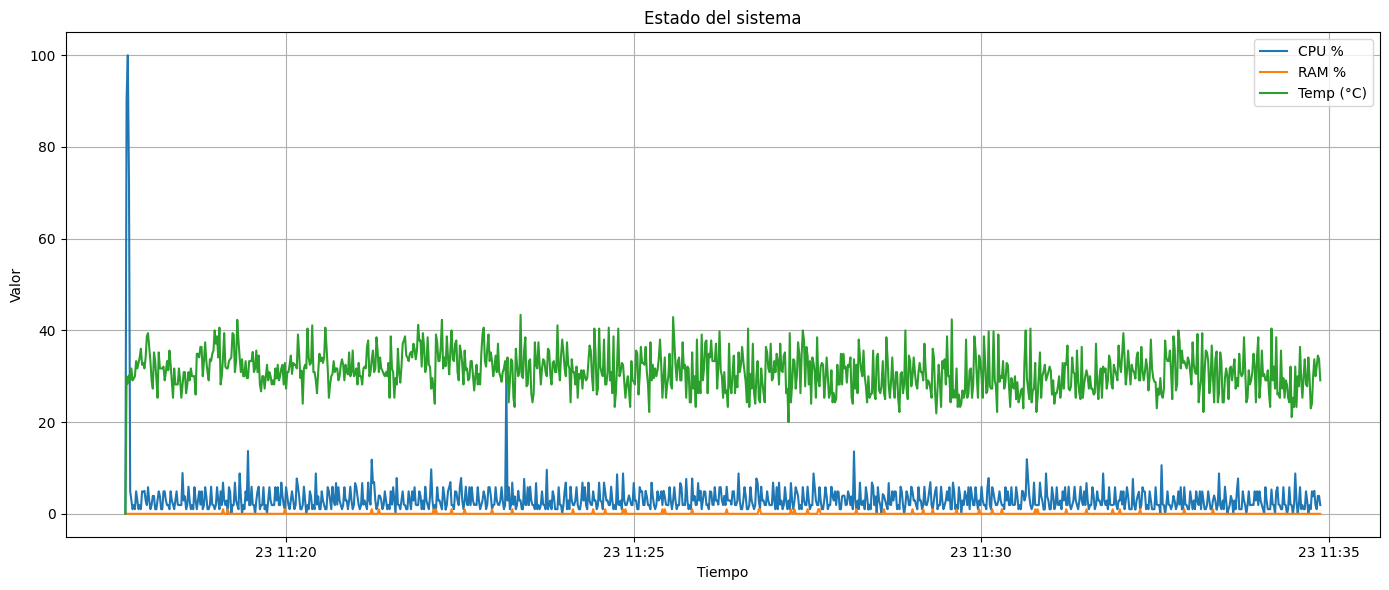

In [16]:

# ==========================
# 1. Sistema
# ==========================
plt.figure(figsize=(14, 6))

plt.plot(df["timestamp_iso"], df["cpu_percent"], label="CPU %")
plt.plot(df["timestamp_iso"], df["ram_percent"], label="RAM %")
plt.plot(df["timestamp_iso"], df["temp_celsius"], label="Temp (°C)")

plt.title("Estado del sistema")
plt.xlabel("Tiempo")
plt.ylabel("Valor")

plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig("system_metrics.png")
plt.show()



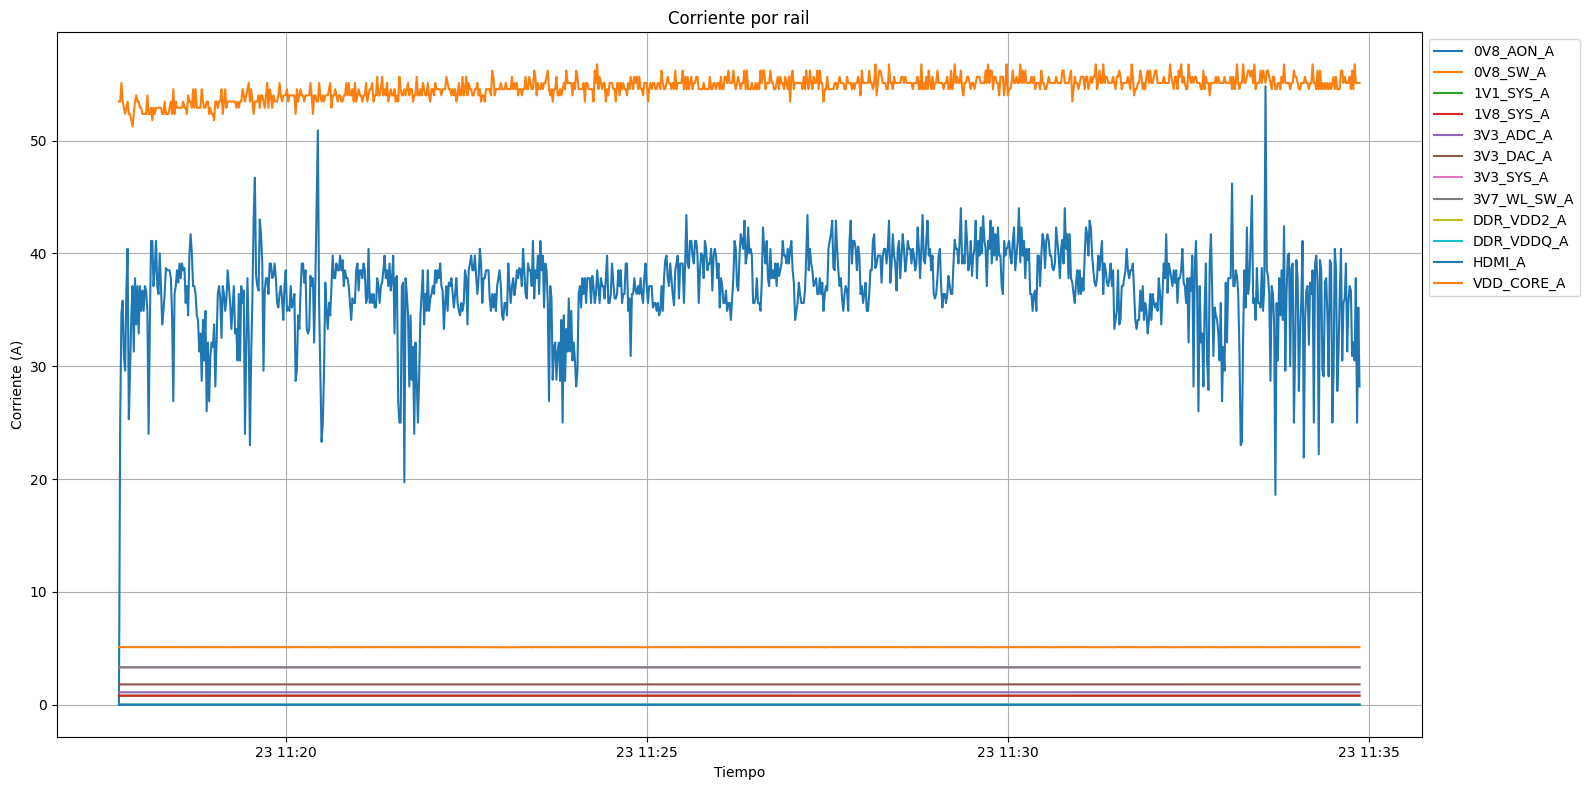

In [17]:

# ==========================
# 2. Corrientes
# ==========================
current_cols = [c for c in df.columns if c.endswith("_A")]

plt.figure(figsize=(16, 8))

for col in current_cols:
    plt.plot(df["timestamp_iso"], df[col], label=col)

plt.title("Corriente por rail")
plt.xlabel("Tiempo")
plt.ylabel("Corriente (A)")

plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.grid()

plt.tight_layout()
plt.savefig("current_metrics.png")
plt.show()



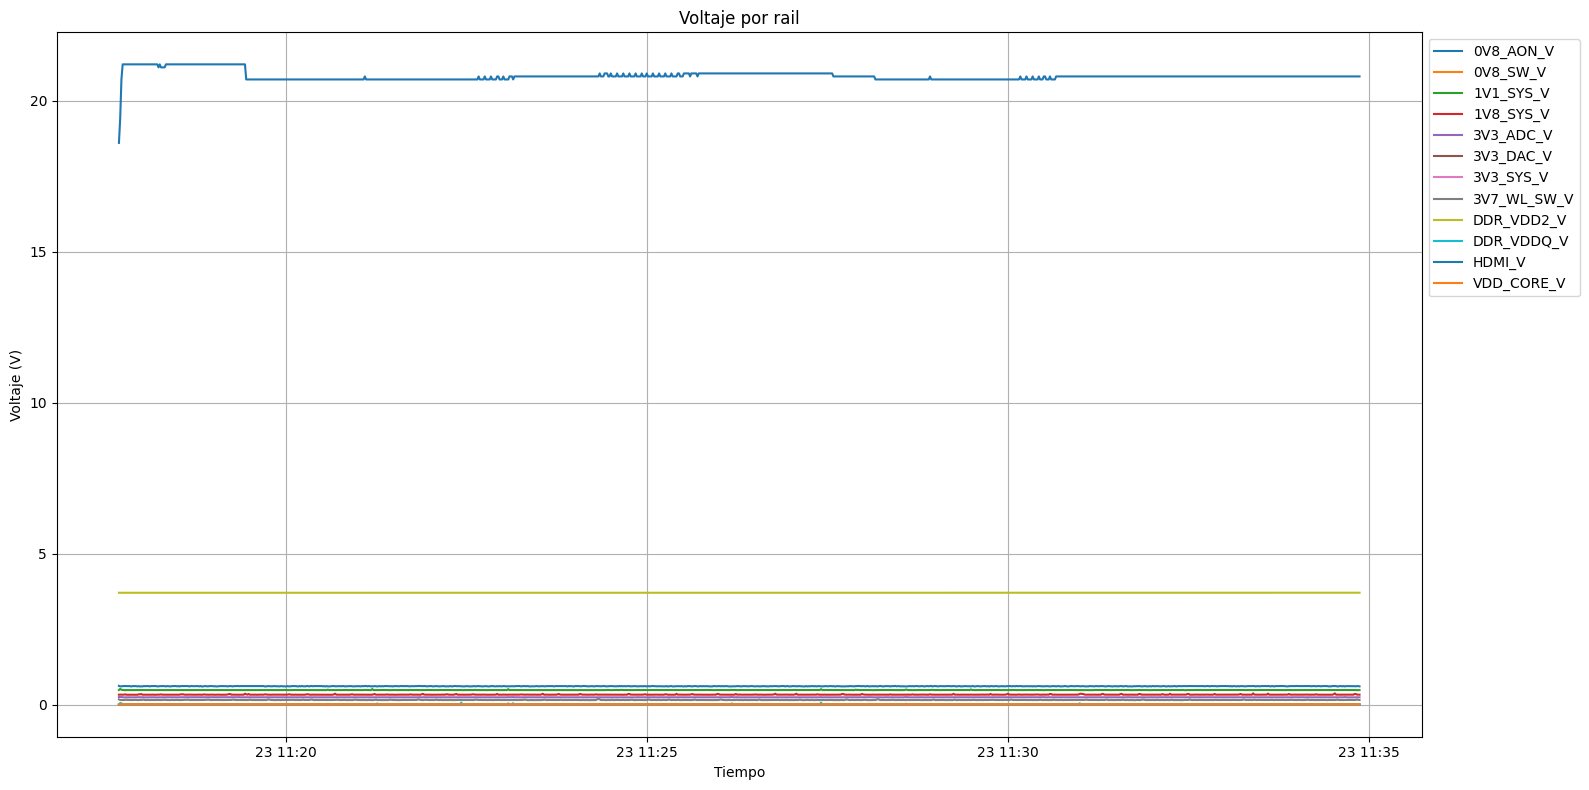

In [18]:

# ==========================
# 3. Tensiones
# ==========================
voltage_cols = [c for c in df.columns if c.endswith("_V")]

plt.figure(figsize=(16, 8))

for col in voltage_cols:
    plt.plot(df["timestamp_iso"], df[col], label=col)

plt.title("Voltaje por rail")
plt.xlabel("Tiempo")
plt.ylabel("Voltaje (V)")

plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.grid()

plt.tight_layout()
plt.savefig("voltage_metrics.png")
plt.show()



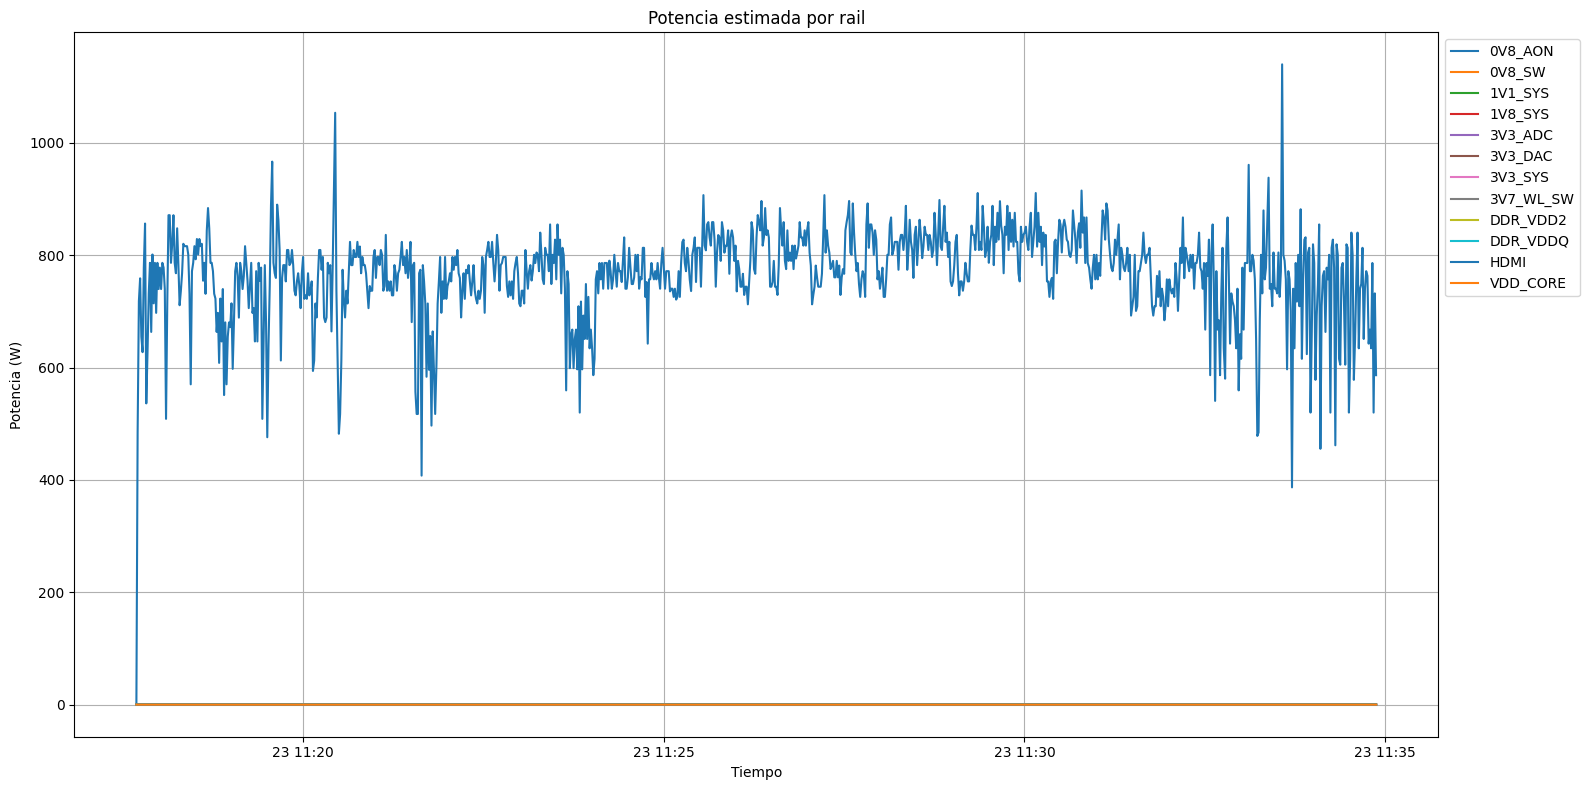

In [19]:

# ==========================
# 4. Potencia estimada
# ==========================

power = pd.DataFrame()
power["timestamp"] = df["timestamp_iso"]

for col in current_cols:

    base = col[:-2]
    voltage = f"{base}_V"

    if voltage in df.columns:
        power[base] = df[col] * df[voltage]


plt.figure(figsize=(16, 8))

for col in power.columns[1:]:
    plt.plot(power["timestamp"], power[col], label=col)

plt.title("Potencia estimada por rail")
plt.xlabel("Tiempo")
plt.ylabel("Potencia (W)")

plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.grid()

plt.tight_layout()
plt.savefig("power_metrics.png")
plt.show()

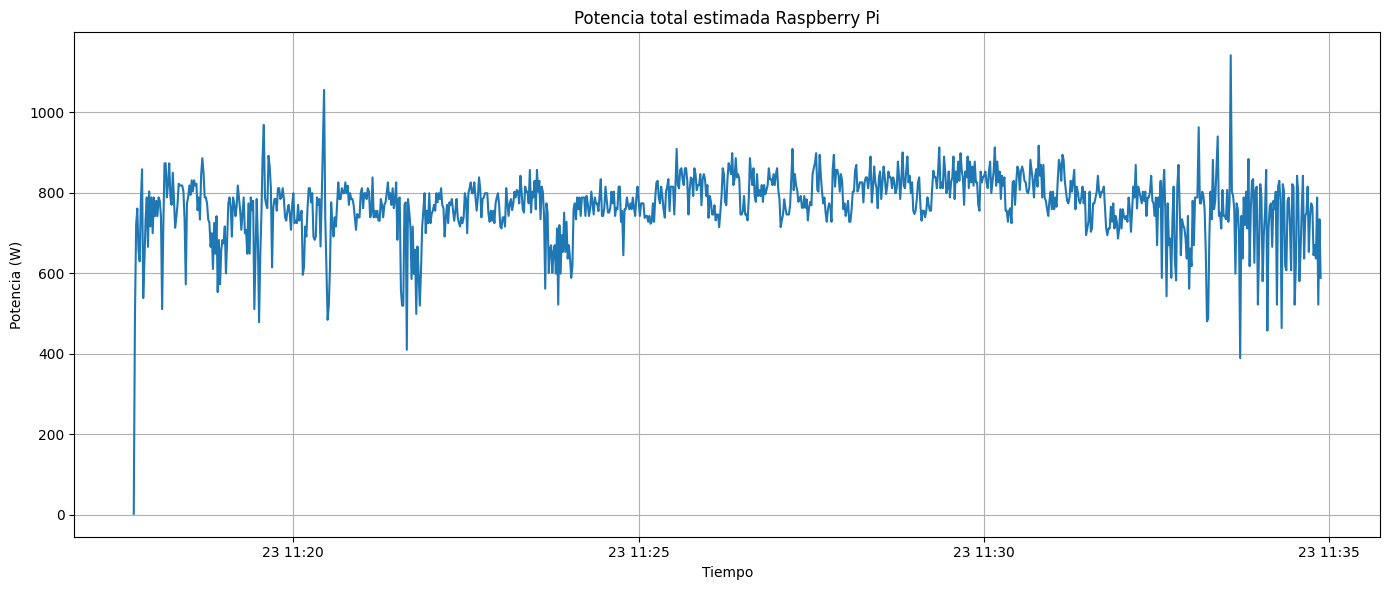

In [20]:
# Potencia general
# Buscar todos los raíles que tienen corriente
current_cols = [c for c in df.columns if c.endswith("_A")]

# Inicializar potencia total
df["power_total_w"] = 0.0


# Sumar potencia de cada rail
for current in current_cols:

    rail = current[:-2]
    voltage = f"{rail}_V"

    if voltage in df.columns:
        df["power_total_w"] += (
            df[current].fillna(0)
            * df[voltage].fillna(0)
        )


# Dibujar gráfico
plt.figure(figsize=(14, 6))

plt.plot(
    df["timestamp_iso"],
    df["power_total_w"],
)

plt.title("Potencia total estimada Raspberry Pi")
plt.xlabel("Tiempo")
plt.ylabel("Potencia (W)")
plt.grid()

plt.tight_layout()
plt.show()